## $\mathbf{\text{Problema de Oseen:}}$

La formulación fuerte del problema de Stokes se escribe como sigue:
$$-\mu\Delta\mathbf{u}+\mathbf{b}\cdot\nabla\mathbf{u}+\nabla p=\mathbf{f}\hspace{0.5cm}\text{en }\Omega$$
$$\nabla\cdot\mathbf{u} = 0\hspace{0.5cm}\text{en }\Omega$$
$$\mathbf{u}=\mathbf{u}_D\,\,\,\text{ en }\partial\Omega$$
donde $\mathbf{b}$ es un campo vectorial puntualmente libre de divergencia $\nabla\cdot\mathbf{b}=0$ (que llamaremos velocidad de adveccion)

### $\mathbf{\text{Formulación Variacional:}}$

Encontrar $\mathbf{u} \in \mathcal{V}= H_D^1(\Omega)^d$ y $p \in Q=L^2_{\int=0}(\Omega)$ tales que:
$$\mu\int_\Omega \nabla\mathbf{u}:\nabla\mathbf{v}+\int_\Omega(\mathbf{b}\cdot\nabla\mathbf{u})\cdot\mathbf{v}-\int_\Omega p\nabla\cdot\mathbf{v}=\int_\Omega\mathbf{f}\cdot\mathbf{v}$$
$$\int_\Omega q\nabla\cdot\mathbf{u}=0$$

In [17]:
# Las librearias que usaremos

from ngsolve import *
from ngsolve.webgui import Draw
from netgen.occ import *
import numpy as np

### $\text{Pares inf-sup estables}$:

Primero comenzamos definiendo la función que automatize el solver de Oseen.

In [23]:
# Ahora en las entradas de la funcion incluimos la velocidad de adveccion b

def SolveOseen(mesh,mu,ff,k,uSol,b):
    V = VectorH1(mesh,order=k+1, dirichlet="left|right|bottom|top") # Almendra (Taylor-Hood)
    Q = H1(mesh,order=k)  # Almedra (Taylor-Hood)
    
    #V = 
    #Q = H1(mesh,order=k) # Juanpi (Mini element)

    X = V*Q

    u,p = X.TrialFunction()  # Funciones Trial
    v,q = X.TestFunction()  # Funciones Test
    
    ConvU = Grad(u).trans*b 

    Oseen = (mu*InnerProduct(grad(u),grad(v)) + ConvU*v - p*div(v) + q*div(u))  # Escribimos el problema variacional completa simbolicamente

    a = BilinearForm(X)  # Creamos una forma bilineal
    a += Oseen*dx  # Agregamos el problema variacional a la forma bilineal
    a.Assemble()   # Ensamblamos la forma bilineal
    
    f = LinearForm(X)   # Creamos una forma lineal
    f += SymbolicLFI(ff*v)   # Agregamos la fuerza externa a la forma lineal a traves de un integrador simbolico
    f.Assemble()   # Ensamblamos la forma lineal
    
    gf = GridFunction(X)   # Creamos una función de malla en X=V*Q para almacenar la solución
    gf.components[0].Set(uSol, definedon=mesh.Boundaries("left|right|bottom|top"))  # Condiciones de Dirichlet para la velocidad
    
    res = f.vec - a.mat*gf.vec  # Calculamos el residuo de la solución inicial
    inv_stokes = a.mat.Inverse(X.FreeDofs())  # Calculamos la inversa de la matriz del sistema de Stokes para los grados de libertad libres
    gf.vec.data += inv_stokes * res   # Actualizamos la solución con el residuo corregido

    return gf  # Esto devuelve el par ordenado (velocidad, presión)

In [24]:
# Ahora resolvemos recursivamente el problema de Stokes mediante un refinamiento uniforme de la malla.

# Comenzamos creando la malla inicial, que es un cuadrado unitario.
square = Rectangle(1.0, 1.0).Face()
    
# Nombra la cara (el dominio interno)
square.faces.name = "domain"
    
# Nombra los bordes
square.edges.name = "default"
square.edges.Min(X).name = "left"
square.edges.Max(X).name = "right"
square.edges.Min(Y).name = "bottom"
square.edges.Max(Y).name = "top"

geo = OCCGeometry(square, dim=2)
mesh = Mesh(geo.GenerateMesh(maxh=0.5))
mesh.Curve(3)

# Datos del problema

b1 = 5.0
b2 = 5.0
b = CF((b1, b2))  # Velocidad de advección constante (div(b)=0)
mu = 1.0   # Viscosidad

u1 = x*(1-x)*y*(1-y)
u2 = (2*x-1)*(y**2)*(0.5-y/3)

usol = CF((u1 , u2))   # Solución manufacturada para la velocidad
psol = x**2*y**2-1/9 # Solución manufacturada para la presión

dxu1 = (1-2*x)*y*(1-y)
dyu1 = x*(1-x)*(1-2*y)
dxu2 = 2*y**2*(0.5-y/3)
dyu2 = (2*x-1)*y*(1-y)

lapu1 = -2*y*(1-y) - 2*x*(1-x)
lapu2 = (2*x-1)*(1-2*y)

dxp = 2*x*y**2
dyp = 2*x**2*y

comp1 = -mu*lapu1 + b1*dxu1 + b2*dxu2 + dxp
comp2 = -mu*lapu2 + b1*dyu1 + b2*dyu2 + dyp

ff = CoefficientFunction((comp1, comp2))    # Fuerza externa calculada a partir de la solución manufacturada

grado = 2  # Usaremos P3/P2 (Taylor-Hood) 

ListaErroresU = []  # Lista para almacenar el número de elementos y el error en cada refinamiento para la velocidad
ListaErroresP = []  # Lista para almacenar el número de elementos y el error en cada refinamiento para la presión


while mesh.ne < 5000:
    
    up = SolveOseen(mesh,mu,ff,grado,usol,b)
    u = up.components[0]
    p = up.components[1]
    c = Integrate(p,mesh,VOL) 
    pp = p - c/Integrate(1,mesh,VOL)  # Corregimos la presión para que tenga media cero

    V = VectorH1(mesh, order = grado+1)
    uSol = GridFunction(V, name="uSol")
    uSol.Set(usol)
    
    ErrorU = sqrt(Integrate(InnerProduct(Grad(u-uSol),Grad(u-uSol)),mesh,VOL))   # Calculamos el error en la velocidad usando la norma H1
    ListaErroresU.append((mesh.ne,ErrorU))    # Listamos el número de elementos y el error para cada refinamiento

    P = H1(mesh, order = grado)
    pSol = GridFunction(P, name="pSol")
    pSol.Set(psol)  # La solución exacta de la presión es cero en este caso

    ErrorP = sqrt(Integrate((pp-pSol)*(pp-pSol),mesh,VOL))   # Calculamos el error en la presión usando la norma L2
    ListaErroresP.append((mesh.ne,ErrorP))    # Listamos el número de elementos y el error para cada refinamiento
    mesh.Refine()  # Refinamiento uniforme de la malla


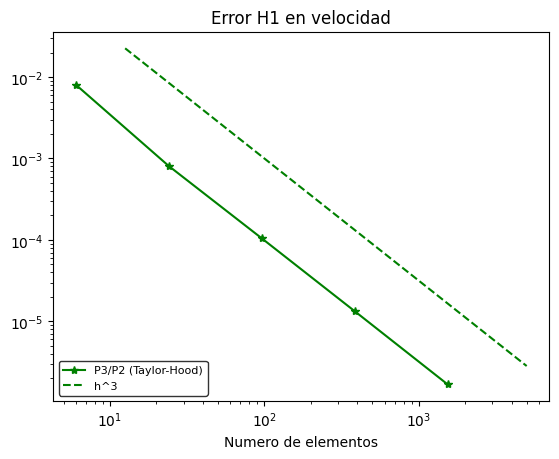

In [25]:
import matplotlib.pyplot as plt
import numpy as np

plt.yscale('log')
plt.xscale('log')
plt.xlabel("Numero de elementos")
plt.title("Error H1 en velocidad")
N1,err = zip(*ListaErroresU)
plt.plot(N1,err, label='P3/P2 (Taylor-Hood)', marker='*',color='green')

x1_func = np.linspace(0, 5000, 400) 
y1_func = 1 / x1_func**((grado+1)/2)
plt.plot(x1_func, y1_func, label='h^3', color='green', linestyle='--')

plt.ion()
plt.legend(
    loc='lower left',
    frameon=True,         # muestra borde del recuadro
    facecolor='white',    # color de fondo del recuadro
    edgecolor='black',    # color del borde
    fontsize=8           # tamaño de letra
)

plt.show()

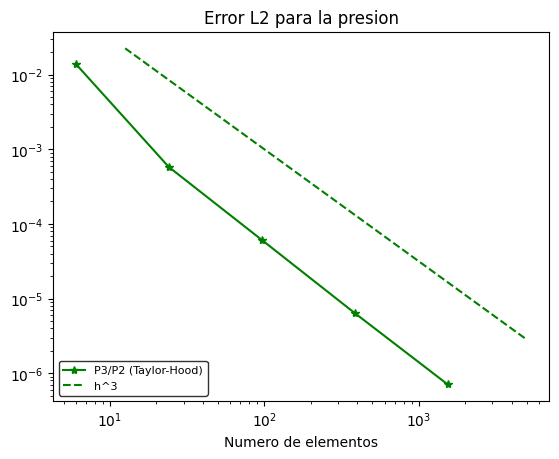

In [26]:
plt.yscale('log')
plt.xscale('log')
plt.xlabel("Numero de elementos")
plt.title("Error L2 para la presion")
N1,err = zip(*ListaErroresP)
plt.plot(N1,err, label='P3/P2 (Taylor-Hood)', marker='*',color='green')

x1_func = np.linspace(0, 5000, 400) 
y1_func = 1 / x1_func**((grado+1)/2)
plt.plot(x1_func, y1_func, label='h^3', color='green', linestyle='--')

plt.ion()
plt.legend(
    loc='lower left',
    frameon=True,         # muestra borde del recuadro
    facecolor='white',    # color de fondo del recuadro
    edgecolor='black',    # color del borde
    fontsize=8           # tamaño de letra
)

plt.show()

### $\text{Oseen Estabilizado:}$